# Exploratory Data Analysis Using Visualization Assignment

### Preparing data for assignment questions:

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Loadeing dataset
df = pd.read_csv("Titanic.csv")

In [36]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [4]:
# Performing basic data exploration using
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
# Checking for number of missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
# Handling Missing Values using median for age , mode for embarked and droping cabin column because of too many missing values. 
df['Age'] = df['Age'].fillna(df['Age'].median()) # 
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop(columns='Cabin', inplace=True)

# Conferming no missing values remain
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Q1. Create a countplot to show the number of passengers by gender.

#### Answer :

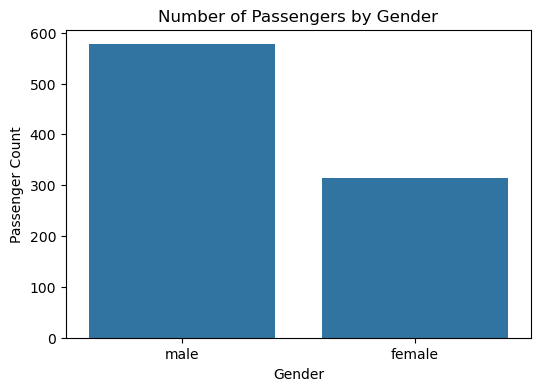

In [11]:
# Countplot for gender
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=df)

# Titles and labels
plt.title("Number of Passengers by Gender")
plt.xlabel("Gender")
plt.ylabel("Passenger Count")

plt.show()

### Interpretation:
- The chart shows gender categories on the x-axis and the number of passengers on the y-axis.
- Different bars represent male and female passengers.
- From the chart, we can observe the number of passengers belonging to each gender.

#### Insight :
- The Titanic dataset contains more male passengers than female passengers.
- This imbalance is important and may impact survival trends, as gender played a crucial role during rescue operations.

### Q2. Create a bar chart to show the number of passengers in each passenger class using different colors.

#### Answer: 

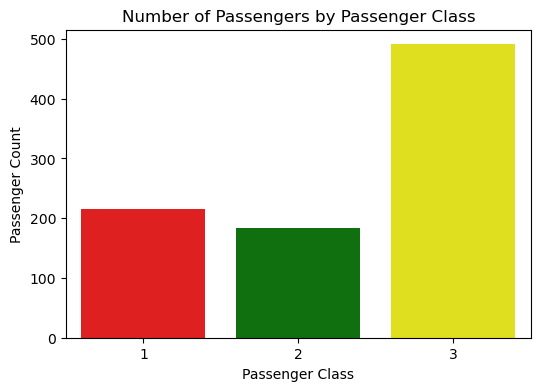

In [18]:
# Createing bar chart
plt.figure(figsize=(6,4))
my_colors = ["red", "green", "yellow"]
sns.countplot(x='Pclass', data=df, hue='Pclass', palette=my_colors, legend=False)

# Adding titles and labels
plt.title("Number of Passengers by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")

plt.show()

### Interpretation: 
- The bar chart displays passenger classes on the x-axis and the number of passengers on the y-axis.
- Different colors represent each class:
  - Red for 1st class
  - Green for 2nd class
  - Yellow for 3rd class
- From the chart, we can clearly observe the number of passengers in each class.

#### Insight:
- The Titanic had a highest concentration of passengers in 3rd class.
- 1st class had fewer passengers than 3rd class but more than 2nd class.
- This indicates that the majority of people traveling on the Titanic were from lower classes.

### Q3. Create a histogram to show the distribution of passenger age.

#### Answer:

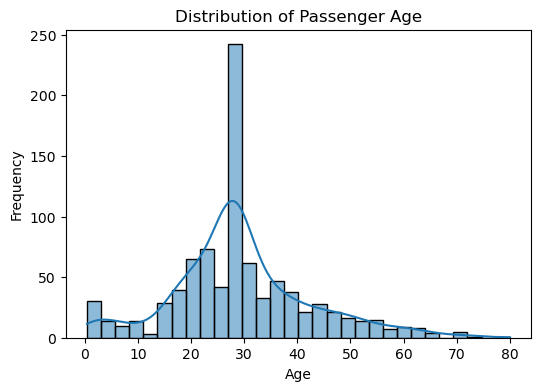

In [23]:
# Createing histogram
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)

# Titles and labels
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Interpretation:

- The histogram shows age values on the x-axis and the number of passengers on the y-axis.
- Most passengers are concentrated between the ages of 18 and 40.
- There are fewer passengers at very young and very old ages.
- The distribution appears slightly right-skewed, with a tail extending toward higher ages.

### Insight:
- The majority of Titanic passengers were young adults.
- There are fewer children then elderly passengers on board.
- Age distribution can play an important role in survival analysis, as certain age groups may have been prioritized during rescue.

### Q4. Create a boxplot to detect outliers in the fare column.

#### Answer:

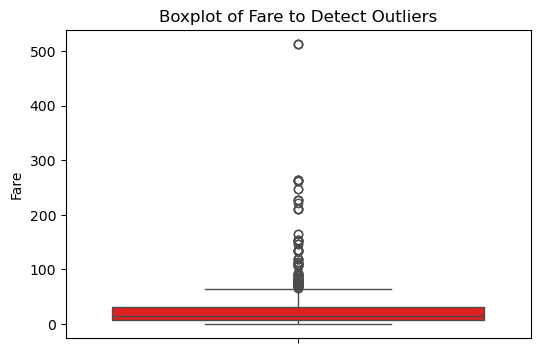

In [31]:
# Createing boxplot
plt.figure(figsize=(6,4))
sns.boxplot(y='Fare', data=df, color='red')

# Titles and labels
plt.title("Boxplot of Fare to Detect Outliers")
plt.ylabel("Fare")

plt.show()

### Interpretation:

- The boxplot shows the distribution of fare values along the y-axis.
- The middle line inside the box represents the median fare.
- The box represents the interquartile range (IQR), where most data points lie.
- Several points are visible above the upper whisker, indicating the presence of outliers.
- These outliers represent passengers who paid significantly higher fares compared to others.

### Insight:

- The Fare column contains multiple high-value outliers.
- This suggests that some passengers paid unusually high ticket prices, likely for luxury accommodations.
- The data is right-skewed, meaning most passengers paid lower fares while a few paid very high amounts.

### Q5. Create a scatterplot to 
- **A.** show the relationship between age and fare.
- **B.** analyze the relationship between family size (SibSp + Parch) and fare.

#### Answer:

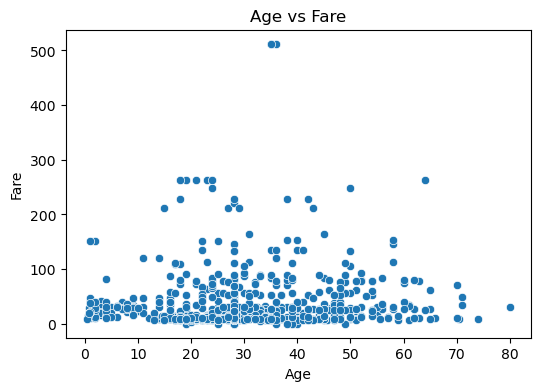

In [34]:
# A. displaying the relationship between age and fare.
# Ctrating scatterplot for Age vs Fare
plt.figure(figsize=(6,4))
sns.scatterplot(x='Age', y='Fare', data=df)

# Titles and labels
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

#### Interpretation:

- The scatterplot shows age on the x-axis and fare on the y-axis.
- Points are evenly spread, indicating no strong relationship between age and fare.
- Passengers of all age groups paid a wide range of fares.

#### Insight:

- There is no clear correlation between age and fare.
- Ticket price does not depend strongly on passenger age.

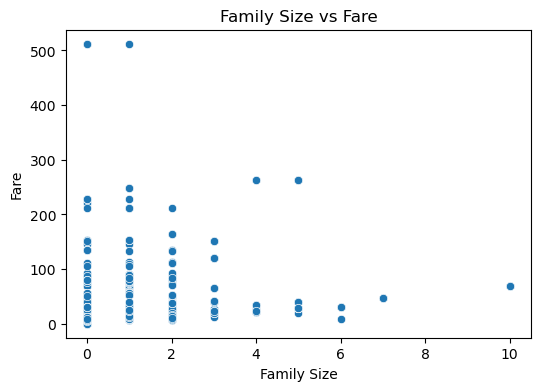

In [33]:
# B. analyzeing the relationship between family size (SibSp + Parch) and fare.
# Createing Family Size column
df['FamilySize'] = df['SibSp'] + df['Parch']

# Scatterplot for Family Size vs Fare
plt.figure(figsize=(6,4))
sns.scatterplot(x='FamilySize', y='Fare', data=df)

# Titles and labels
plt.title("Family Size vs Fare")
plt.xlabel("Family Size")
plt.ylabel("Fare")

plt.show()

### Interpretation:
- The scatterplot shows family size on the x-axis and fare on the y-axis.
- As family size increases, the number of passengers decreases.

### Insight:
- Most passengers with small family sizes (0–2) paid a wide range of fares.
- Most passengers traveled alone or in small families.
- Fare variation is likely influenced more by passenger class than family size.

### Q6. Create a countplot to show survival count by gender.


#### Answer:

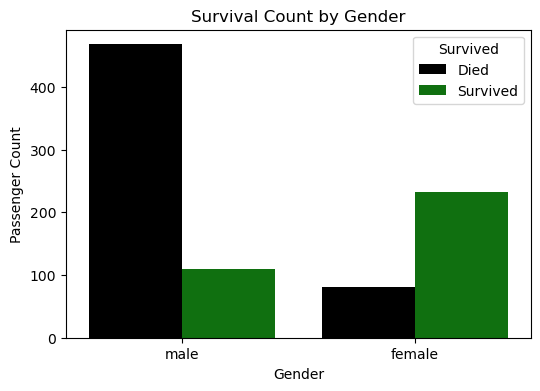

In [49]:
# Createing countplot
plt.figure(figsize=(6,4))
my_color = ["black", "green"]
sns.countplot(x='Sex', hue='Survived', data=df, palette=my_color, legend=False)

# Titles and labels
plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Passenger Count")

plt.legend(title="Survived", labels=["Died", "Survived"])

plt.show()

### Interpretation:
- The chart shows gender on the x-axis and passenger count on the y-axis.
- Different colors represent survival status (Green for survived and Red for not survived).
- A large number of male passengers did not survive compared to those who survived.
- In contrast, a higher proportion of female passengers survived compared to males.

### Insight:
- Gender had a significant impact on survival during the Titanic disaster.
- Female passengers had a much higher survival rate than male passengers.
- This supports the "women and children first" evacuation policy followed during the incident.

### Q7. Create a bar chart to show survival by passenger class.


#### Answer:

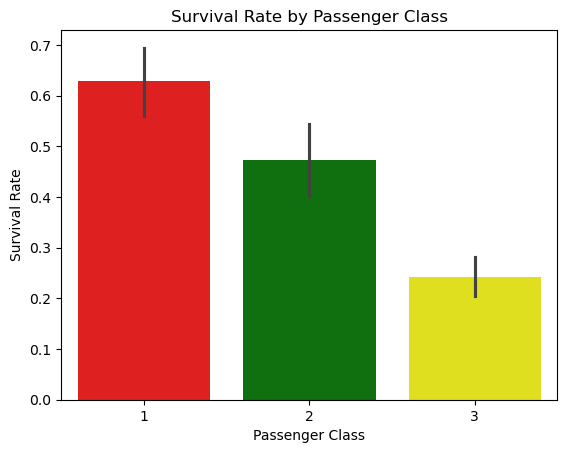

In [48]:
# Createing bar chart to shows survival rate by class
plt.figure()
sns.barplot(x='Pclass', y='Survived', data=df, hue='Pclass' , palette=my_colors, legend=False)

# Titles and labels
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

### Interpretation:
- The bar chart shows passenger class on the x-axis and survival rate on the y-axis.
- 1st class passengers have the highest survival rate.
- 2nd class passengers have a second highest survival rate.
- 3rd class passengers have the lowest survival rate.

### Insight:
- Passenger class had a strong impact on survival.
- Higher-class passengers (especially 1st class) were more likely to survive.
- Lower-class passengers (3rd class) had the lowest chances of survival.
- This suggests that access to resources and lifeboats was better for higher-class passengers.

### Q8. Create a heatmap to show correlation between numerical variables.

#### Answers:

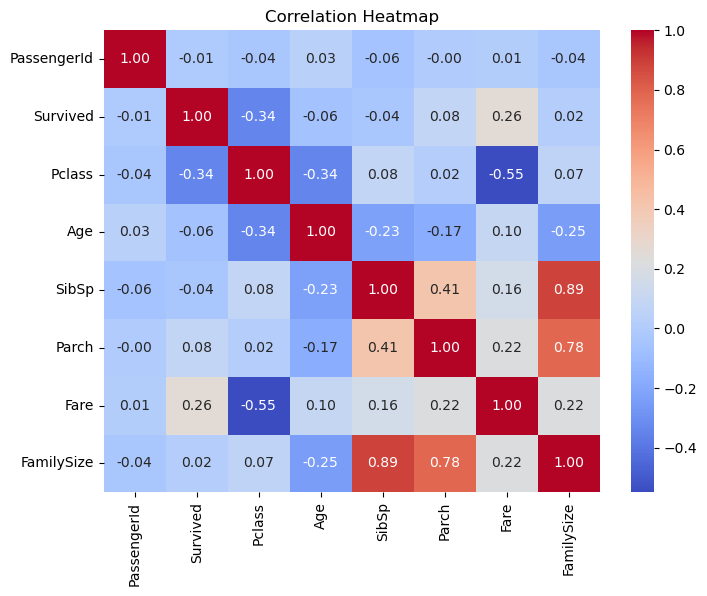

In [51]:
# Selecting numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64'])

# Computeing correlation matrix
corr_matrix = num_cols.corr()

# Createing heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Title
plt.title("Correlation Heatmap")

plt.show()

### Interpretation:
- The heatmap shows correlation values between numerical variables ranging from -1 to +1.
- Values closer to +1 indicate strong positive correlation, while values closer to -1 indicate strong negative correlation.
- Survival has:
  - A negative correlation with Pclass (higher class number = lower survival)
  - A slight negative correlation with Age
  - A positive correlation with Fare
- Most other variables show weak correlations with each other.

### Insight
- Passenger class (Pclass) and fare are important factors influencing survival.
- Higher fare (often linked to higher class) increases chances of survival.
- Age has a weak effect on survival.
- Overall, no extremely strong correlations exist, indicating multiple factors influence survival rather than a single variable.

### Q9. Identify which passenger class paid the highest fare on average.

#### Answer:

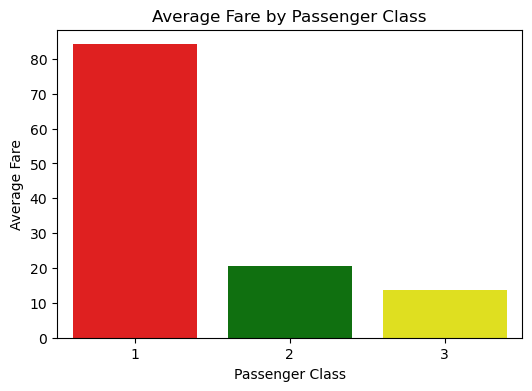

In [57]:
# Calculateing average fare by class
avg_fare = df.groupby('Pclass')['Fare'].mean()

# Bar chart for average fare
plt.figure(figsize=(6,4))
sns.barplot(x=avg_fare.index, y=avg_fare.values,hue=avg_fare.index , palette=my_colors, legend=False)

# Titles and labels
plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")

plt.show()

### Interpretation:
- The bar chart shows passenger class on the x-axis and average fare on the y-axis.
- 1st class passengers paid the highest average fare.
- 2nd class passengers paid a second highest average fare.
- 3rd class passengers paid the lowest average fare.

### Insight:
- 1st class passengers paid the highest fares on average.
- Fare is strongly linked to passenger class, reflecting differences in luxury and facilities.
- This also explains why higher-class passengers had better survival chances, as they had better access to resources.

### Q10. Write at least 5 insights from the dataset based on your visualizations.




#### Answer:

#### Based analysis the following key insights can be drawn:

##### 1: Gender Distribution:
The dataset contains significantly more male passengers than female passengers. However, females had a higher survival rate compared to males.

##### 2: Passenger Class Distribution:
Most passengers belonged to 3rd class, indicating that the ship carried a large number of lower-income passengers.

##### 3: Survival by Gender:
Female passengers were more likely to survive than male passengers. This supports the "women and children first" policy followed during evacuation.

##### 4: Survival by Passenger Class:
1st class passengers had the highest survival rate because they had better survival chances, as they had better access to resources.

##### 5: Fare Distribution:
Fare data is highly skewed with several outliers. A small number of passengers paid very high ticket prices.

##### 6: Age Distribution:
Most passengers were between 18–40 years old.

##### 7: Correlation Findings:
Survival on the Titanic was influenced by multiple factors such as gender, passenger class, and fare.Socioeconomic status played a major role in determining outcomes during the disaster.Higher-class passengers and females had a significant advantage in survival.
